<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-classification-experiments/densnet_exp01(colab).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import zipfile
import os
import shutil # Import shutil for rmtree

# --- Start of added cleanup commands ---
# Remove previous split_dataset if it exists
if os.path.exists('/content/split_dataset'):
    shutil.rmtree('/content/split_dataset')
    print("Removed /content/split_dataset to free up space.")

# Remove any partial or old fabric_dataset_raw if it exists
if os.path.exists('/content/fabric_dataset_raw'):
    shutil.rmtree('/content/fabric_dataset_raw')
    print("Removed /content/fabric_dataset_raw to free up space.")
# --- End of added cleanup commands ---

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/fabric_classification_dataset.zip'
extract_path = '/content/fabric_dataset_raw'

print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extracted ✅")

for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

Removed /content/split_dataset to free up space.
Removed /content/fabric_dataset_raw to free up space.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting...
Extracted ✅
/content/fabric_dataset_raw -> 0 files
/content/fabric_dataset_raw/fabric_dataset -> 1 files
/content/fabric_dataset_raw/fabric_dataset/Silk -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Cotton -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Viscose -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Wool -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Velvet -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Chiffon -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Polyester -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Denim -> 401 files
/content/fabric_dataset_raw/fabric_dataset/Linen -> 400 files


In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   98G  9.9G  91% /


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import os, random, shutil
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
def find_dataset_root(base_path):
    expected_classes = {'chiffon','cotton','denim','linen','polyester','silk','velvet','viscose','wool'}
    for root, dirs, files in os.walk(base_path):
        if expected_classes.issubset(set(d.lower() for d in dirs)):
            return root
    return base_path

dataset_root = find_dataset_root(extract_path)
print("Dataset root:", dataset_root)

classes = sorted([d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))])
print("Classes:", classes)

for c in classes:
    count = len(os.listdir(os.path.join(dataset_root, c)))
    print(f"{c}: {count} original images")

Dataset root: /content/fabric_dataset_raw/fabric_dataset
Classes: ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']
Chiffon: 400 original images
Cotton: 400 original images
Denim: 401 original images
Linen: 400 original images
Polyester: 400 original images
Silk: 400 original images
Velvet: 400 original images
Viscose: 400 original images
Wool: 400 original images


In [ ]:
split_base = '/content/split_dataset'
if os.path.exists(split_base):
    shutil.rmtree(split_base)

for split in ['train', 'val', 'test']:
    for c in classes:
        os.makedirs(f'{split_base}/{split}/{c}', exist_ok=True)

for c in classes:
    src_folder = os.path.join(dataset_root, c)
    imgs = [f for f in os.listdir(src_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    random.shuffle(imgs)

    n = len(imgs)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    for i, img in enumerate(imgs):
        src = os.path.join(src_folder, img)
        if i < train_end:
            dst = f'{split_base}/train/{c}/{img}'
        elif i < val_end:
            dst = f'{split_base}/val/{c}/{img}'
        else:
            dst = f'{split_base}/test/{c}/{img}'
        os.symlink(src, dst)  # symlink = zero extra disk space

train_dir = f'{split_base}/train'
val_dir = f'{split_base}/val'
test_dir = f'{split_base}/test'

for split in ['train', 'val', 'test']:
    total = sum(len(os.listdir(f'{split_base}/{split}/{c}')) for c in classes)
    print(f"{split}: {total} images")

train: 2520 images
val: 540 images
test: 541 images


In [ ]:
class FabricDataGenerator(Sequence):
    """
    Applies rotate/flip transformations IN MEMORY at training time -
    no extra files are written to disk. Only rotation (90/180/270) and
    flipping are used (no zoom/crop/brightness/contrast), preserving the
    fabric's natural texture and color as they appear in the dataset.
    """
    def __init__(self, image_paths, labels, batch_size=32, target_size=(224, 224),
                 augment=False, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.augment = augment
        self.shuffle = shuffle

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        batch_x, batch_y = [], []
        for path, label in zip(batch_paths, batch_labels):
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.target_size)

            if self.augment:
                choice = random.choice(['orig', 'rot90', 'rot180', 'rot270', 'flip_h', 'flip_v'])
                if choice == 'rot90':
                    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                elif choice == 'rot180':
                    img = cv2.rotate(img, cv2.ROTATE_180)
                elif choice == 'rot270':
                    img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
                elif choice == 'flip_h':
                    img = cv2.flip(img, 1)
                elif choice == 'flip_v':
                    img = cv2.flip(img, 0)
                # 'orig' = no change

            batch_x.append(img)
            batch_y.append(label)

        batch_x = np.array(batch_x, dtype=np.float32)
        batch_x = tf.keras.applications.densenet.preprocess_input(batch_x)
        return batch_x, np.array(batch_y)

    def on_epoch_end(self):
        if self.shuffle:
            combined = list(zip(self.image_paths, self.labels))
            random.shuffle(combined)
            self.image_paths, self.labels = zip(*combined)
            self.image_paths, self.labels = list(self.image_paths), list(self.labels)

print("✅ Data generator ready (runtime rotate/flip, zero disk usage)")

✅ Data generator ready (runtime rotate/flip, zero disk usage)


In [ ]:
class_indices = {cls: i for i, cls in enumerate(classes)}

def build_paths_labels(folder):
    paths, labels = [], []
    for cls in classes:
        cls_dir = os.path.join(folder, cls)
        for img_name in os.listdir(cls_dir):
            paths.append(os.path.join(cls_dir, img_name))
            labels.append(class_indices[cls])
    return paths, labels

train_paths, train_labels = build_paths_labels(train_dir)
val_paths, val_labels = build_paths_labels(val_dir)
test_paths, test_labels = build_paths_labels(test_dir)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

train_gen = FabricDataGenerator(train_paths, train_labels, batch_size=32, augment=True, shuffle=True)
val_gen = FabricDataGenerator(val_paths, val_labels, batch_size=32, augment=False, shuffle=False)
test_gen = FabricDataGenerator(test_paths, test_labels, batch_size=32, augment=False, shuffle=False)

Train: 2520 | Val: 540 | Test: 541


In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=np.unique(train_labels), y=train_labels
)
class_weights = dict(enumerate(class_weights_array))

polyester_idx = class_indices['Polyester']
class_weights[polyester_idx] *= 0.5

wool_idx = class_indices['Wool']
class_weights[wool_idx] = min(class_weights[wool_idx], 1.0)

viscose_idx = class_indices['Viscose']
class_weights[viscose_idx] *= 0.6

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(0.5), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(0.6), 8: np.float64(1.0)}


In [ ]:
base_model = tf.keras.applications.DenseNet121(
    include_top=False, weights="imagenet", input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(classes), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,307,337 (27.88 MB)

 Trainable params: 267,273 (1.02 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("/content/best_fabric_model.keras",
                              monitor="val_loss", save_best_only=True, verbose=1)

In [ ]:
print("\n--- Stage 1: Training the new layers only ---")
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history1 = model.fit(
    train_gen, validation_data=val_gen, epochs=12,
    callbacks=[reduce_lr, early_stopping, checkpoint],
    class_weight=class_weights
)


--- Stage 1: Training the new layers only ---
Epoch 1/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.4208 - loss: 1.7406 
Epoch 1: val_loss improved from None to 0.87331, saving model to /content/best_fabric_model.keras

Epoch 1: finished saving model to /content/best_fabric_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 1582s 20s/step - accuracy: 0.5623 - loss: 1.2372 - val_accuracy: 0.7685 - val_loss: 0.8733 - learning_rate: 0.0010
Epoch 2/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.6899 - loss: 0.7446 
Epoch 2: val_loss improved from 0.87331 to 0.66949, saving model to /content/best_fabric_model.keras

Epoch 2: finished saving model to /content/best_fabric_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 1488s 19s/step - accuracy: 0.7020 - loss: 0.7394 - val_accuracy: 0.8333 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 3/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.7560 - loss: 0.6331 
Epoch 3: val_loss improved from 0.66949 to 0.55274, saving model to /content/be

In [ ]:
print("\n--- Stage 2: Fine-tuning top layers ---")
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history2 = model.fit(
    train_gen, validation_data=val_gen, epochs=20,
    callbacks=[reduce_lr, early_stopping, checkpoint],
    class_weight=class_weights
)

print("✅ Training completed!")


--- Stage 2: Fine-tuning top layers ---
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.8124 - loss: 0.4883 
Epoch 1: val_loss did not improve from 0.34061
79/79 ━━━━━━━━━━━━━━━━━━━━ 1691s 21s/step - accuracy: 0.8155 - loss: 0.4837 - val_accuracy: 0.8759 - val_loss: 0.3954 - learning_rate: 1.0000e-05
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.8147 - loss: 0.4860 
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_loss did not improve from 0.34061
79/79 ━━━━━━━━━━━━━━━━━━━━ 1543s 20s/step - accuracy: 0.8075 - loss: 0.4823 - val_accuracy: 0.8870 - val_loss: 0.3829 - learning_rate: 1.0000e-05
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.8168 - loss: 0.4882 
Epoch 3: val_loss did not improve from 0.34061
79/79 ━━━━━━━━━━━━━━━━━━━━ 1558s 20s/step - accuracy: 0.8187 - loss: 0.4754 - val_accuracy: 0.8907 - val_loss: 0.3712 - learning_rate: 5.0000e-06
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/ste

17/17 ━━━━━━━━━━━━━━━━━━━━ 275s 15s/step
Test Accuracy: 89.09%

              precision    recall  f1-score   support

     Chiffon       0.88      0.95      0.91        60
      Cotton       0.86      0.95      0.90        60
       Denim       0.90      0.92      0.91        61
       Linen       0.90      0.92      0.91        60
   Polyester       0.84      0.68      0.75        60
        Silk       0.87      0.78      0.82        60
      Velvet       0.94      1.00      0.97        60
     Viscose       0.83      0.82      0.82        60
        Wool       0.98      1.00      0.99        60

    accuracy                           0.89       541
   macro avg       0.89      0.89      0.89       541
weighted avg       0.89      0.89      0.89       541



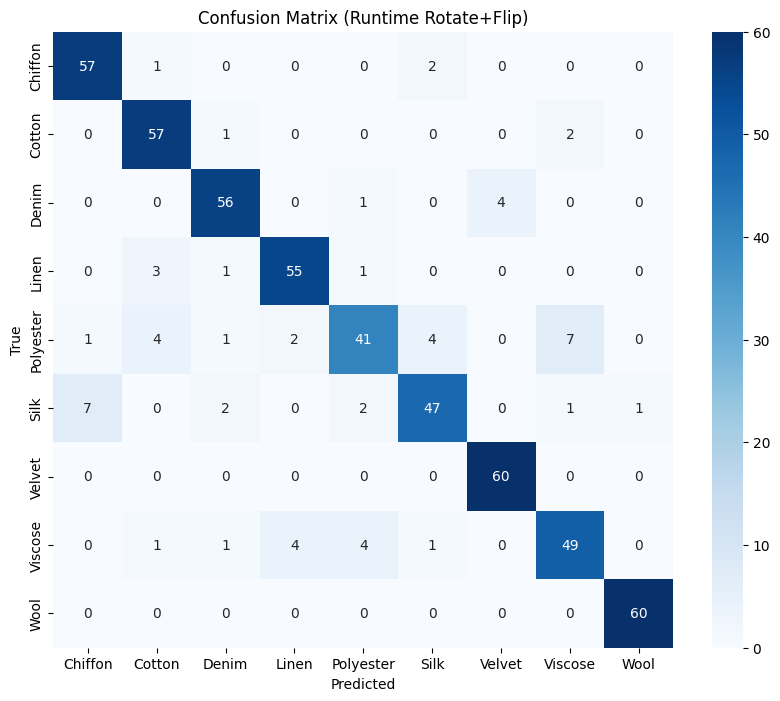

Chiffon: 57/60 (95.0%) | Confused with: [('Silk', np.int64(2)), ('Cotton', np.int64(1))]
Cotton: 57/60 (95.0%) | Confused with: [('Viscose', np.int64(2)), ('Denim', np.int64(1))]
Denim: 56/61 (91.8%) | Confused with: [('Velvet', np.int64(4)), ('Polyester', np.int64(1))]
Linen: 55/60 (91.7%) | Confused with: [('Cotton', np.int64(3)), ('Denim', np.int64(1)), ('Polyester', np.int64(1))]
Polyester: 41/60 (68.3%) | Confused with: [('Viscose', np.int64(7)), ('Cotton', np.int64(4)), ('Silk', np.int64(4)), ('Linen', np.int64(2)), ('Chiffon', np.int64(1)), ('Denim', np.int64(1))]
Silk: 47/60 (78.3%) | Confused with: [('Chiffon', np.int64(7)), ('Denim', np.int64(2)), ('Polyester', np.int64(2)), ('Viscose', np.int64(1)), ('Wool', np.int64(1))]
Velvet: 60/60 (100.0%) | Confused with: []
Viscose: 49/60 (81.7%) | Confused with: [('Linen', np.int64(4)), ('Polyester', np.int64(4)), ('Cotton', np.int64(1)), ('Denim', np.int64(1)), ('Silk', np.int64(1))]
Wool: 60/60 (100.0%) | Confused with: []


In [ ]:
best_model = tf.keras.models.load_model("/content/best_fabric_model.keras")

y_pred_probs = best_model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels[:len(y_pred)])

test_acc = np.mean(y_pred == y_true)
print(f"Test Accuracy: {test_acc*100:.2f}%\n")

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (Runtime Rotate+Flip)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.show()

for i, cls in enumerate(classes):
    total = cm[i].sum()
    correct = cm[i][i]
    confused_with = [(classes[j], cm[i][j]) for j in range(len(classes)) if j != i and cm[i][j] > 0]
    confused_with.sort(key=lambda x: -x[1])
    print(f"{cls}: {correct}/{total} ({correct/total*100:.1f}%) | Confused with: {confused_with}")

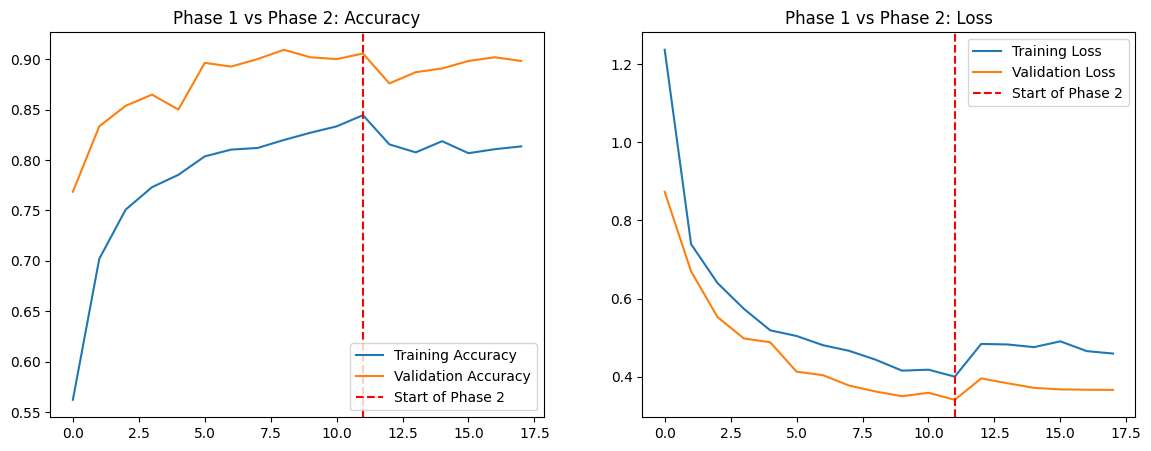

In [ ]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=len(history1.history['accuracy'])-1, color='r', linestyle='--', label='Start of Phase 2')
plt.title('Phase 1 vs Phase 2: Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=len(history1.history['loss'])-1, color='r', linestyle='--', label='Start of Phase 2')
plt.title('Phase 1 vs Phase 2: Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
drive_save_path = '/content/drive/MyDrive/fabric_classifier_model'
os.makedirs(drive_save_path, exist_ok=True)

shutil.copy("/content/best_fabric_model.keras", f"{drive_save_path}/fabric_classifier.keras")

import json
class_info = {"classes": classes, "input_size": [224, 224], "preprocessing": "densenet"}
with open(f'{drive_save_path}/class_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)

print(f"✅ Model saved to Google Drive: {drive_save_path}")

✅ Model saved to Google Drive: /content/drive/MyDrive/fabric_classifier_model


📸 Fabric image ekක් upload karanna...


Saving chiffon3.jpeg to chiffon3.jpeg


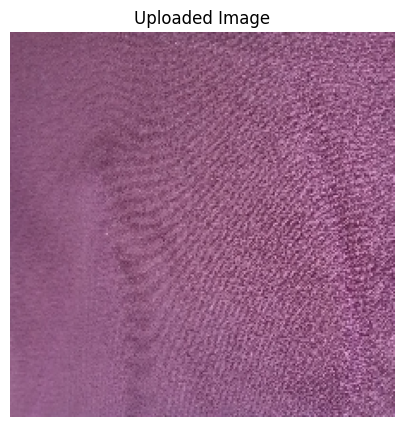

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Predicted: Chiffon (49.77%)
Top-3:
  Chiffon: 49.77%
  Viscose: 24.79%
  Cotton: 14.69%


In [ ]:
from google.colab import files

print("📸 Fabric image ekක් upload karanna...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸Upload image..


Saving denim 2.jpg to denim 2.jpg


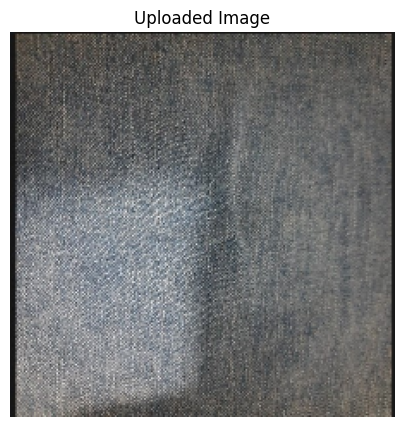

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step

Predicted: Denim (99.62%)
Top-3:
  Denim: 99.62%
  Velvet: 0.37%
  Silk: 0.01%


In [ ]:
from google.colab import files

print("📸Upload image..")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving denim.jfif to denim (1).jfif


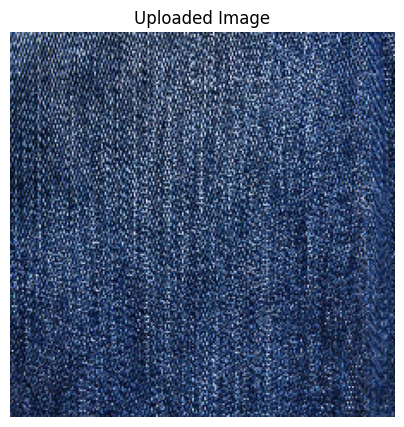

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step

Predicted: Denim (99.68%)
Top-3:
  Denim: 99.68%
  Velvet: 0.32%
  Linen: 0.00%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving IMG-20260719-WA0086.jpg to IMG-20260719-WA0086 (1).jpg


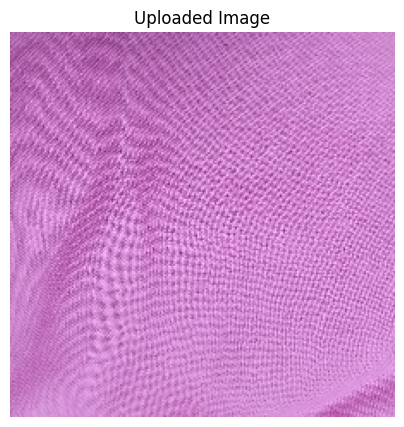

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step

Predicted: Cotton (84.77%)
Top-3:
  Cotton: 84.77%
  Polyester: 12.85%
  Viscose: 2.17%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving IMG-20260719-WA0079.jpg to IMG-20260719-WA0079.jpg


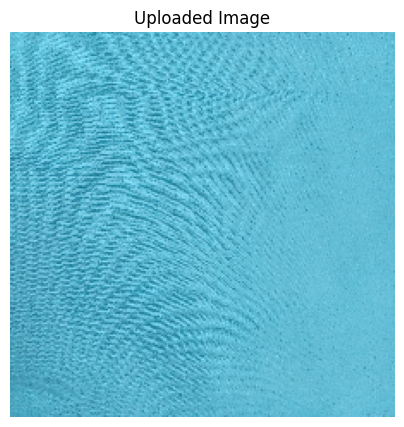

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step

Predicted: Linen (79.47%)
Top-3:
  Linen: 79.47%
  Silk: 9.16%
  Chiffon: 6.47%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving IMG-20260719-WA0084.jpg to IMG-20260719-WA0084.jpg


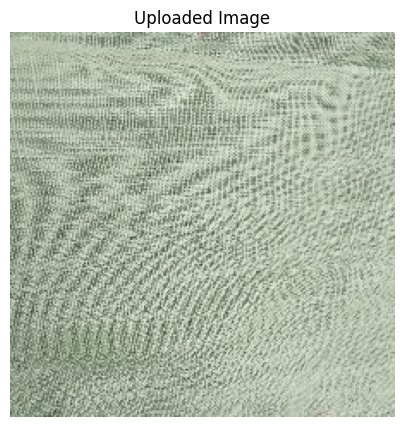

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step

Predicted: Linen (96.34%)
Top-3:
  Linen: 96.34%
  Polyester: 1.33%
  Cotton: 1.27%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving silk1.jpg to silk1.jpg


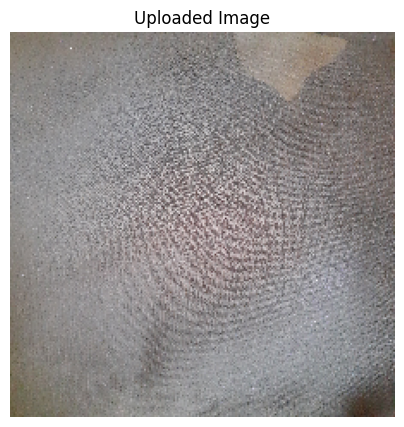

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step

Predicted: Silk (52.55%)
Top-3:
  Silk: 52.55%
  Velvet: 28.24%
  Chiffon: 8.04%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving wool (2).jpg to wool (2).jpg


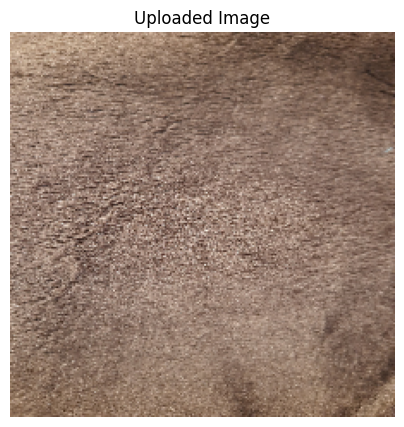

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step

Predicted: Wool (99.55%)
Top-3:
  Wool: 99.55%
  Velvet: 0.25%
  Chiffon: 0.13%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving viscose_captured.jpg to viscose_captured.jpg


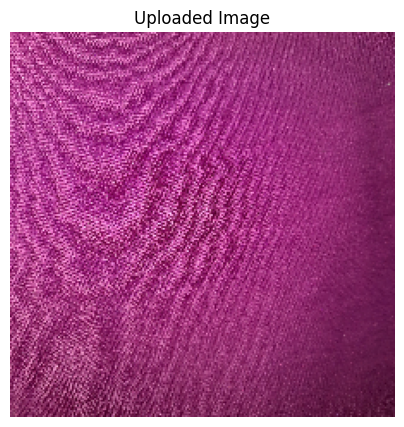

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step

Predicted: Viscose (94.90%)
Top-3:
  Viscose: 94.90%
  Polyester: 4.10%
  Cotton: 0.41%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving IMG-20260719-WA0087.jpg to IMG-20260719-WA0087.jpg


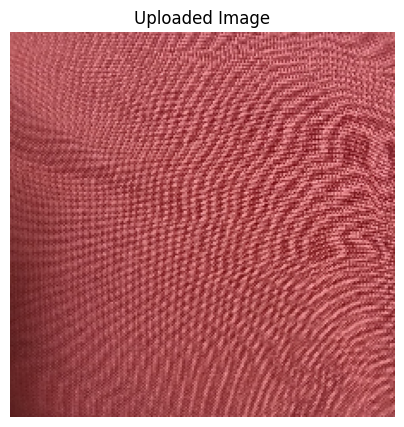

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step

Predicted: Viscose (94.57%)
Top-3:
  Viscose: 94.57%
  Cotton: 3.04%
  Polyester: 0.96%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving velvet.jpg to velvet.jpg


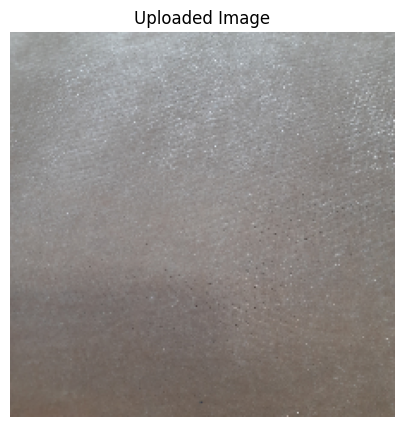

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step

Predicted: Velvet (90.78%)
Top-3:
  Velvet: 90.78%
  Wool: 7.95%
  Silk: 0.63%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving poly.jpg to poly.jpg


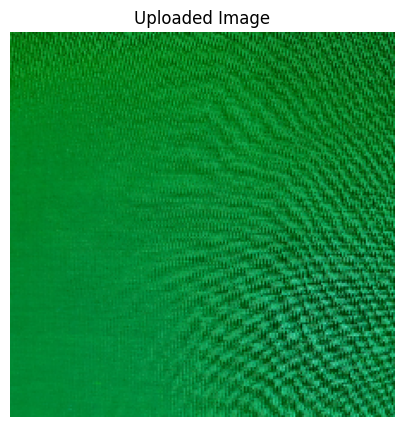

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step

Predicted: Polyester (67.42%)
Top-3:
  Polyester: 67.42%
  Chiffon: 25.73%
  Silk: 3.36%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving wool (2).jpg to wool (2) (1).jpg


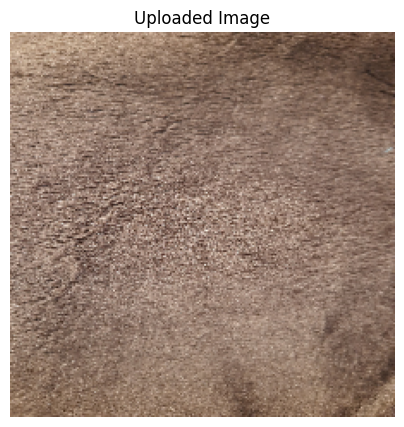

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step

Predicted: Wool (99.55%)
Top-3:
  Wool: 99.55%
  Velvet: 0.25%
  Chiffon: 0.13%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving IMG-20260719-WA0074.jpg to IMG-20260719-WA0074.jpg


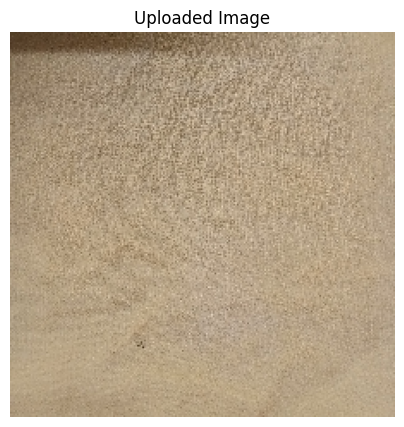

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step

Predicted: Chiffon (94.85%)
Top-3:
  Chiffon: 94.85%
  Wool: 2.61%
  Velvet: 1.29%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸  upload image...


Saving IMG-20260719-WA0082.jpg to IMG-20260719-WA0082 (1).jpg


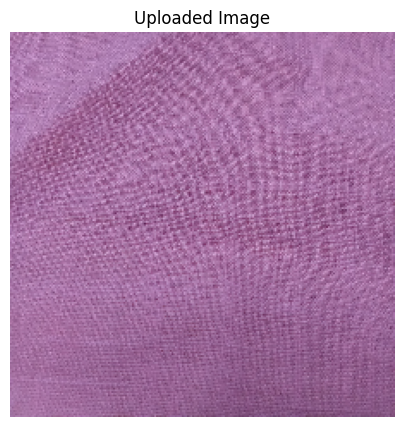

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step

Predicted: Cotton (95.21%)
Top-3:
  Cotton: 95.21%
  Viscose: 2.90%
  Linen: 0.70%


In [ ]:
from google.colab import files

print("📸  upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")